#**Data Visualization**

## **1) Loading the Taxis Dataset**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
sns.set_theme(style="whitegrid",palette="dark")

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the 'taxis' dataset
df = sns.load_dataset("taxis")

## **2)Understanding the Dataset**

In [ ]:
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [ ]:
df.tail()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn
6432,2019-03-13 19:31:22,2019-03-13 19:48:02,1,3.85,15.0,3.36,0.0,20.16,green,credit card,Boerum Hill,Windsor Terrace,Brooklyn,Brooklyn


In [ ]:
df.shape

(6433, 14)

In [ ]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')

In [ ]:
sorted(df['passengers'].unique())

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6)]

In [ ]:
(df['passengers']==0).sum()

np.int64(96)

In [ ]:
((df['distance']==0.0) & (df['total']>df['total'].mean())).sum()

np.int64(16)

In [ ]:
(df[['distance','fare','tip','tolls','total']] < 0).sum()

,0
distance,0
fare,0
tip,0
tolls,0
total,0


In [ ]:
df[df['pickup'] > df['dropoff']]

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough


In [ ]:
df.duplicated().sum()

np.int64(0)

#### **Observations from the dataset**

* The dataset contains **trip related information**.
* Both **numerical** and **categorical** columns present in the dataset.
* We can derive following information from the columns:
   * Date and time related information
      * Only 2019 March month trip information present in pickup and dropoff columns.
   * Location related information
   * Fare related information
   * Passenger count
   * Payment methods
* The dataset also contains different **taxi service categories represented by colour column**, which operate across various boroughs of New York City.
    * **Yellow** - Traditional NYC taxis,pick up passengers anywhere in Manhattan and at airports and operates in busy city areas.
    * **Green** - also called **“Boro Taxis”** and these are introduced to improve taxi availability in outer boroughs.
* **No unnecessary columns** present in the dataset.
* Some rows contain **passenger count as 0**, which is not realistic for normal taxi trips. These rows may represent incorrect or missing records, so they need to be removed.
* A few rows have **0 distance but unusually high total fare values**. Since a trip with zero distance should not generate high charges, these rows were treated as anomalies and should remove from the dataset.
* We do not have any negative values present in the numerical columns.
* We do not have duplicates in the given dateset.
* Overall the data appeared to be **structed** and very well **organised**.

## **Problem Statement**

* Find which day generates the highest revenue.
* Analyze the effect of passenger count on revenue.
* Study the relationship between distance and fare.
* Compare revenue between yellow and green taxis.
* Identify the most preferred payment method.
* Find which areas or boroughs generate the highest revenue.
* Analyze customer behavior based on the tip amount.
* Identify factors affecting total trip revenue.

## **3) Data Cleaning**

#### **Remove Invalid Records**

In [ ]:
df=df[df['passengers']>0]
df.shape

(6337, 14)

In [ ]:
df=df[~((df['distance']==0.0) & (df['total']>df['total'].mean()))]
df.shape

(6321, 14)

#### **Handling missing values**

In [ ]:
# Check for missing values in the dataset and identify columns with missing data.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6321 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6321 non-null   datetime64[ns]
 1   dropoff          6321 non-null   datetime64[ns]
 2   passengers       6321 non-null   int64         
 3   distance         6321 non-null   float64       
 4   fare             6321 non-null   float64       
 5   tip              6321 non-null   float64       
 6   tolls            6321 non-null   float64       
 7   total            6321 non-null   float64       
 8   color            6321 non-null   object        
 9   payment          6285 non-null   object        
 10  pickup_zone      6301 non-null   object        
 11  dropoff_zone     6285 non-null   object        
 12  pickup_borough   6301 non-null   object        
 13  dropoff_borough  6285 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(1), o

* Missing values are present in **categorical columns** such as payment, pickup_zone, dropoff_zone, pickup_borough, and dropoff_borough.
* Since these are categorical columns, **mode** imputation can be used to replace missing values.


In [ ]:
# ➢ Impute missing values using appropriate strategies based on the column type
 # (e.g., using mean, median, or mode for numerical columns, and mode for categorical columns).

df.fillna({'payment':df['payment'].mode()[0]},inplace=True)
df.fillna({'pickup_borough':df['pickup_borough'].mode()[0]},inplace=True)
df.fillna({'dropoff_borough':df['dropoff_borough'].mode()[0]},inplace=True)
df.fillna({'pickup_zone':df['pickup_zone'].mode()[0]},inplace=True)
df.fillna({'dropoff_zone':df['dropoff_zone'].mode()[0]},inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6321 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6321 non-null   datetime64[ns]
 1   dropoff          6321 non-null   datetime64[ns]
 2   passengers       6321 non-null   int64         
 3   distance         6321 non-null   float64       
 4   fare             6321 non-null   float64       
 5   tip              6321 non-null   float64       
 6   tolls            6321 non-null   float64       
 7   total            6321 non-null   float64       
 8   color            6321 non-null   object        
 9   payment          6321 non-null   object        
 10  pickup_zone      6321 non-null   object        
 11  dropoff_zone     6321 non-null   object        
 12  pickup_borough   6321 non-null   object        
 13  dropoff_borough  6321 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(1), o

In [ ]:
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6321,6321,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000,6321.000000
mean,2019-03-16 08:11:04.813162240,2019-03-16 08:25:26.473817600,1.563202,3.033248,12.987212,1.957902,0.317690,18.386266
min,2019-02-28 23:29:03,2019-02-28 23:32:35,1.000000,0.000000,1.000000,0.000000,0.000000,1.300000
25%,2019-03-08 15:11:18,2019-03-08 15:41:23,1.000000,0.990000,6.500000,0.000000,0.000000,10.800000
50%,2019-03-15 21:31:51,2019-03-15 21:50:02,1.000000,1.650000,9.500000,1.660000,0.000000,14.160000
75%,2019-03-23 17:14:52,2019-03-23 17:28:59,2.000000,3.220000,15.000000,2.760000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,23.190000,24.020000,174.820000
std,NaN,NaN,1.198826,3.833432,11.299079,2.382202,1.396899,13.492416


#### **Handling Outliers**

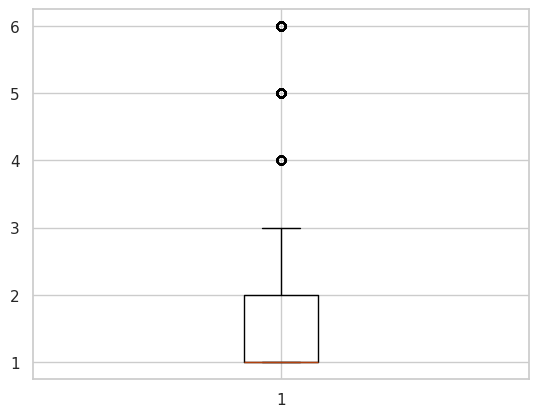

In [ ]:
plt.boxplot(df['passengers'])
plt.show()

* Even though the  boxplot shows higher passenger counts as outliers, these values are realistic for taxi services hence we should retaine passenger statistical outliers in the dataset.

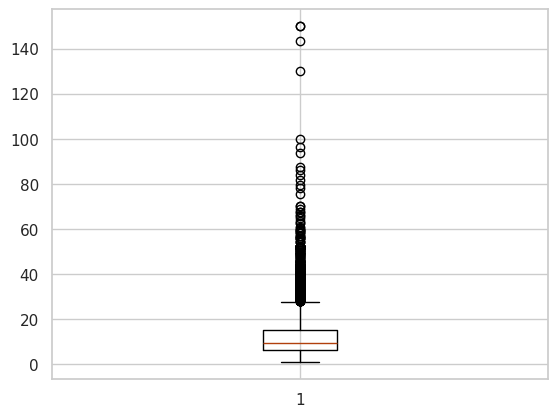

In [ ]:
plt.boxplot(df['fare'])
plt.show()

In [ ]:
Q1=df['fare'].quantile(0.25)
Q2=df['fare'].quantile(0.50)
Q3=df['fare'].quantile(0.75)
IFR=Q3-Q1
Upper_limit=Q3 + (1.5 *IFR)
Lower_limit=Q1 - (1.5 *IFR)
print(f"{Upper_limit},{Lower_limit}")
Q2

27.75,-6.25


np.float64(9.5)

**Total Outliers count from fare column**

In [ ]:
high_fare=df[df['fare']>Upper_limit]
high_fare.shape

(570, 14)

**Out of 570 outliers in fare column,517 rows are related to airport trips,long_distance trips,peaktime trips and yellow taxi service which has premium service trips.Those can not be ignored.**

In [ ]:
high_fare['hour'] = high_fare['pickup'].dt.hour

((high_fare['pickup_zone'].str.contains('Airport')) |
((high_fare['dropoff_zone'].str.contains('Airport'))) |
(high_fare['distance']>high_fare['distance'].mean()) |
((high_fare['color']=='yellow')) |
((high_fare['hour'] >= 3) & (high_fare['hour'] <= 5)) |
((high_fare['hour'] >= 15) & (high_fare['hour'] <= 16))).sum()

np.int64(517)

**Checking whether weekday and weekend services effecting outliers or not**

In [ ]:
high_fare['day_name']=high_fare['pickup'].dt.day_name()
high_fare.groupby('day_name')['fare'].mean()

,fare
day_name,
Friday,43.980619
Monday,43.979143
Saturday,41.980290
Sunday,41.577000
Thursday,39.893678
Tuesday,42.021351
Wednesday,41.316893


In [ ]:
high_fare.groupby('passengers')['fare'].mean()

,fare
passengers,
1,41.665463
2,43.692308
3,45.521739
4,40.666667
5,39.022727
6,45.117647


**Weekdays or weekends and passengers count does not effecting the fare of the trip**

In [ ]:
remaining_outliers = high_fare[
    ~(
        (high_fare['pickup_zone'].str.contains('Airport')) |
        (high_fare['dropoff_zone'].str.contains('Airport')) |
        (high_fare['distance'] > high_fare['distance'].mean()) |
        (high_fare['color'] == 'yellow') |
        ((high_fare['hour'] >= 3) & (high_fare['hour'] <= 5)) |
        ((high_fare['hour'] >= 15) & (high_fare['hour'] <= 16))
    )
]
print(remaining_outliers.shape)
(remaining_outliers['color']=='green').sum()

(53, 16)


np.int64(53)

In [ ]:
from pickleshare import collections_abc
df.groupby('color')['fare'].mean()

,fare
color,
green,13.926691
yellow,12.815663


**After analyzing the fare outliers, we found that they are mostly caused by real-world trip conditions like airport travel, long rides, peak hours, and taxi service type. Therefore, the outliers were considered valid and were not removed from the dataset.**

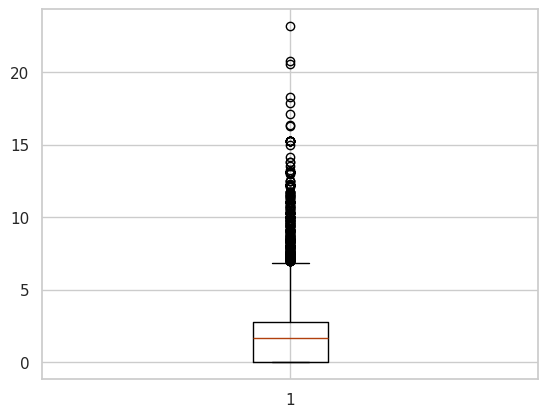

In [ ]:
plt.boxplot(df['tip'])
plt.show()

In [ ]:
Q1_tip=df['tip'].quantile(0.25)
Q2_tip=df['tip'].quantile(0.50)
Q3_tip=df['tip'].quantile(0.75)

IQR_tip=Q3_tip-Q1_tip
upper_limit_tip=Q3_tip + (1.5 * IQR_tip)
lower_limit_tip=Q1_tip - (1.5 * IQR_tip)
print(f"{upper_limit_tip},{lower_limit_tip}")

high_tip=df[df['tip']>upper_limit_tip]
high_tip.shape

6.8999999999999995,-4.14


(272, 14)

In [ ]:
high_tip = high_tip.copy()
high_tip['hour'] = high_tip['pickup'].dt.hour

In [ ]:
((high_tip['pickup_zone'].str.contains('Airport')) |
((high_tip['dropoff_zone'].str.contains('Airport'))) |
(high_tip['distance']>high_tip['distance'].mean()) |
((high_tip['color']=='yellow')) |
((high_tip['hour'] >= 3) & (high_tip['hour'] <= 5)) |
((high_tip['hour'] >= 15) & (high_tip['hour'] <= 16))).sum()

np.int64(266)

In [ ]:
remaining_outliers_tip = high_tip[
    ~(
        (high_tip['pickup_zone'].str.contains('Airport')) |
        (high_tip['dropoff_zone'].str.contains('Airport')) |
        (high_tip['distance'] > high_tip['distance'].mean()) |
        (high_tip['color'] == 'yellow') |
        ((high_tip['hour'] >= 3) & (high_tip['hour'] <= 5)) |
        ((high_tip['hour'] >= 15) & (high_tip['hour'] <= 16))
     )
]

print(remaining_outliers_tip.shape)

(remaining_outliers_tip['color'] == 'green').sum()

(6, 15)


np.int64(6)

**Tip outliers are caused by the same real-world travel conditions as fare outliers, so they were treated as valid data and not removed.**

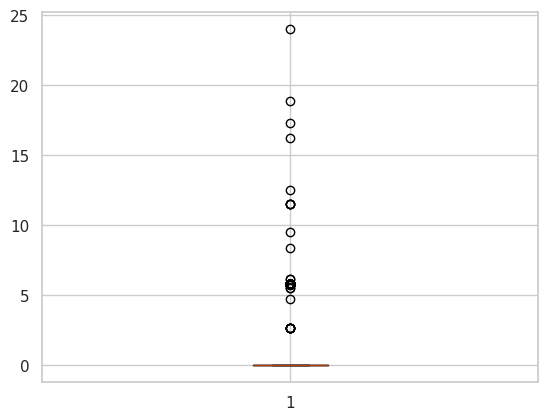

In [ ]:
plt.boxplot(df['tolls'])
plt.show()

**Most trips have no toll charges, so toll values appear as outliers.
These are valid trips, so the toll outliers were retained.**

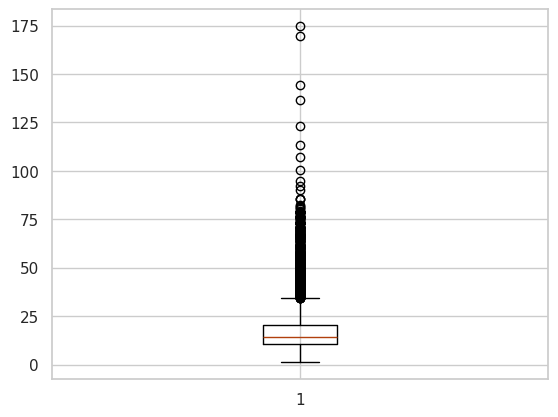

In [ ]:
plt.boxplot(df['total'])
plt.show()

**Total outliers are caused by the same valid trip conditions as fare and tip outliers, so they were not removed.**

## **3) Visualizations using Matplotlib/Pandas Plot:**

### **Line Plot**

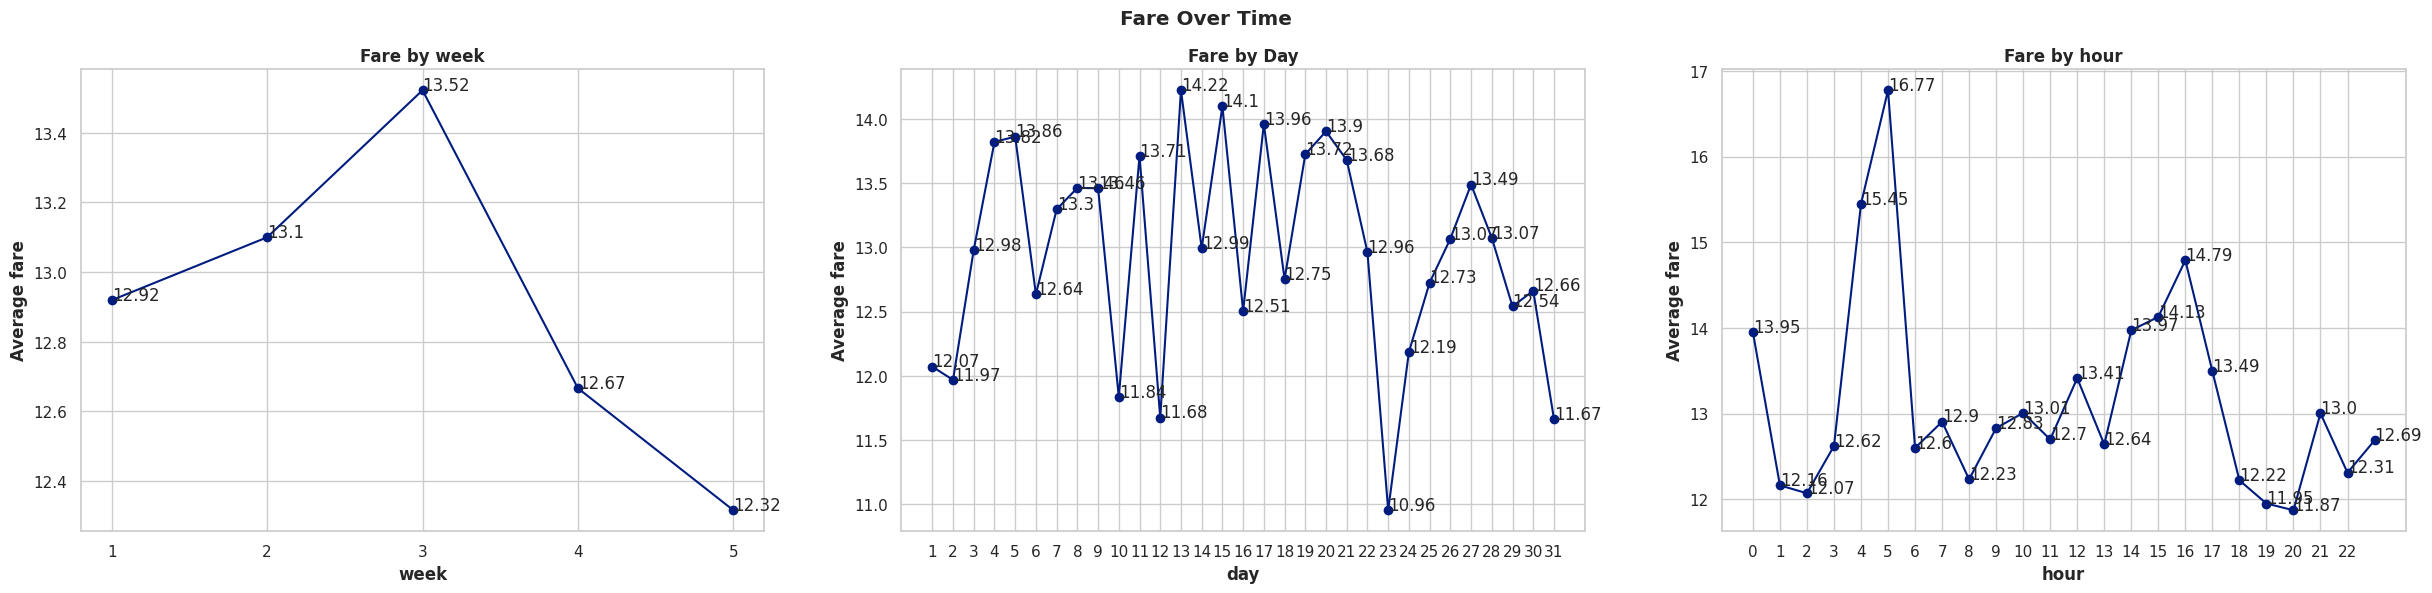

In [ ]:
# Plot a line chart to visualize the fare over time, using the pickup timestamp as the x-axis and fare as the y-axis.
# Ensure the pickup column is converted to a datetime format before plotting.
fig,ax=plt.subplots(1,3,figsize=(30,6))
fig.suptitle('Fare Over Time',fontweight='bold')

df['day']=df['pickup'].dt.day
df['hour']=df['pickup'].dt.hour
df['week']=((df['pickup'].dt.day-1)//7)+1

fare_by_day=df.groupby('day')['fare'].mean()
fare_by_hour=df.groupby('hour')['fare'].mean()
fare_by_week=df.groupby('week')['fare'].mean()

ax[0].plot(fare_by_week.index,fare_by_week.values,marker='o')
ax[0].set_xlabel('week',fontweight='bold')
ax[0].set_ylabel('Average fare',fontweight='bold')
ax[0].set_title('Fare by week',fontweight='bold')
ax[0].set_xticks(range(1,6))

ax[1].plot(fare_by_day.index,fare_by_day.values,marker='o')
ax[1].set_xlabel('day',fontweight='bold')
ax[1].set_ylabel('Average fare',fontweight='bold')
ax[1].set_title('Fare by Day',fontweight='bold')
ax[1].set_xticks(range(1,32))

ax[2].plot(fare_by_hour.index,fare_by_hour.values,marker='o')
ax[2].set_xlabel('hour',fontweight='bold')
ax[2].set_ylabel('Average fare',fontweight='bold')
ax[2].set_title('Fare by hour',fontweight='bold')
ax[2].set_xticks(range(0,23))

for x,y in zip(fare_by_week.index,fare_by_week.values):
  ax[0].text(x,y,round(y,2))

for x,y in zip(fare_by_day.index,fare_by_day.values):
  ax[1].text(x,y,round(y,2))

for x,y in zip(fare_by_hour.index,fare_by_hour.values):
  ax[2].text(x,y,round(y,2))

plt.show()

### **Insights**

* Week 3 has higher average fares compared to other weeks.
* Fare prices decrease at the end of the month, and Week 5 has lower fares.
* Fare prices change frequently from day to day without a clear pattern.
* Higher fares are seen during morning hours.
* Fare prices increase again during evening hours.
* Afternoon and late-night hours have comparatively lower fares.


### **Bar Chart**

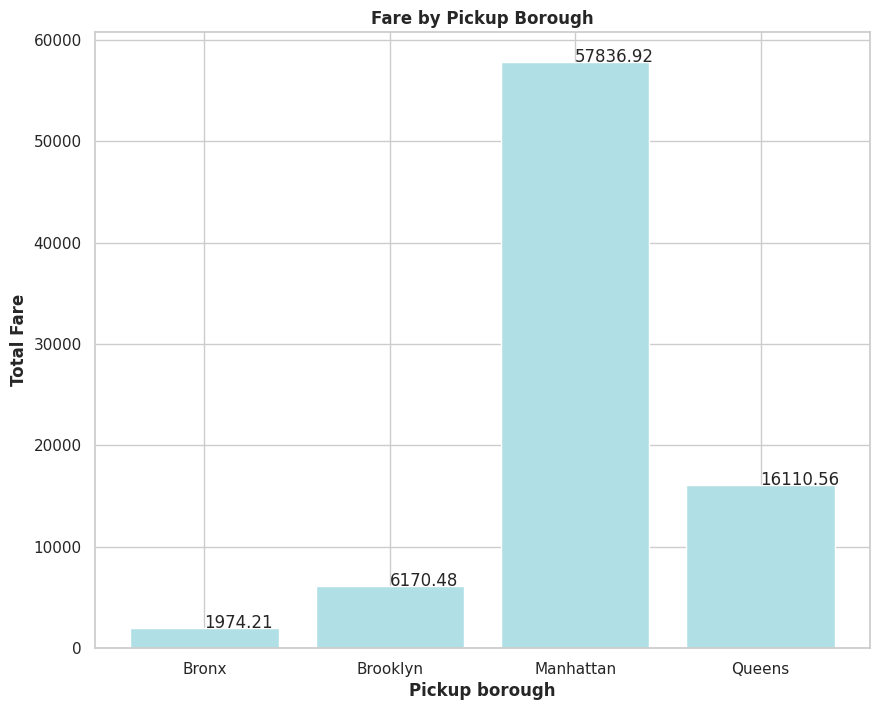

In [ ]:
# Create a bar chart to show the total fare for each pickup_borough. Group the data by pickup_borough and sum the fare for each group
df1=df.groupby('pickup_borough')['fare'].sum()
plt.figure(figsize=(10,8))
plt.bar(df1.index,df1.values,color='powderblue')
plt.title("Fare by Pickup Borough",fontweight='bold')
plt.xlabel("Pickup borough",fontweight='bold')
plt.ylabel("Total Fare",fontweight='bold')

for x,y in zip(df1.index,df1.values):
  plt.text(x,y,round(y,2))
plt.show()


####**Insights**

*Pickup trips from Manhattan generate the highest total fare, while Bronx has the lowest.

###**Pie Chart**

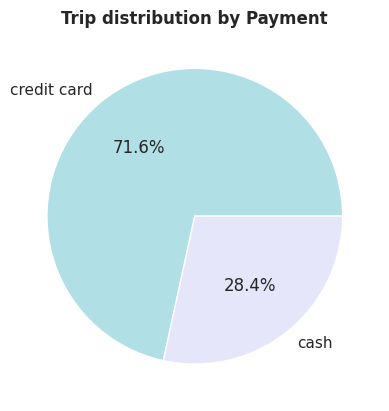

In [ ]:
# Plot a pie chart showing the distribution of trips based on the payment method (credit card, cash, etc.). Each slice should represent the count of trips for a specific payment method.
df2 = df['payment'].value_counts()
plt.pie(df2.values,labels=df2.index,colors=['powderblue','lavender'],autopct='%1.1f%%')
plt.title("Trip distribution by Payment",fontweight='bold')
plt.show()

**Insights:**

* Most trips are paid using credit cards, indicating higher usage of digital payment methods compared to cash payments.

#### **Histogram**

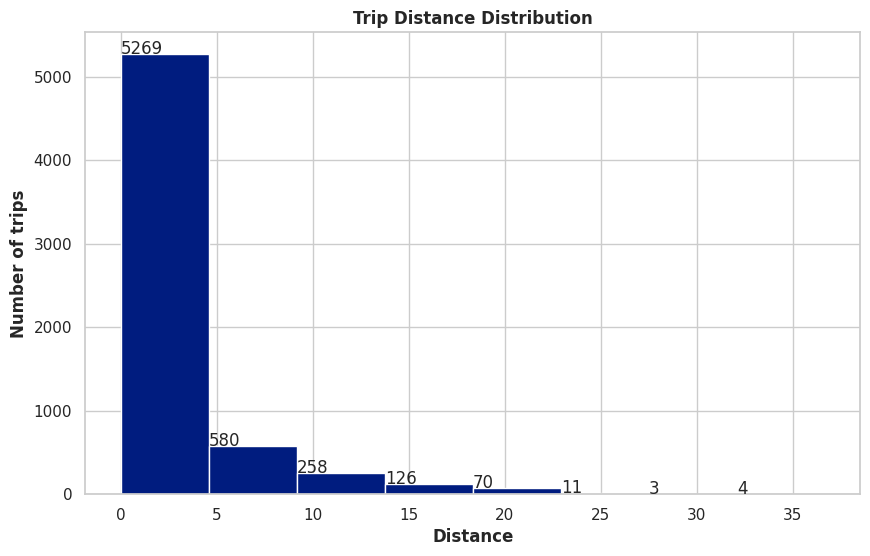

In [ ]:
from matplotlib import patches
# Create a histogram to visualize the distribution of distance. Customize the number of bins for better granularity and ensure the plot is easy to interpret.
plt.figure(figsize=(10,6))
counts,bins,patches = plt.hist(df['distance'],bins=8)
plt.xlabel("Distance",fontweight="bold")
plt.ylabel("Number of trips",fontweight="bold")
plt.title("Trip Distance Distribution",fontweight="bold")

for count,bin in zip(counts,bins):
  plt.text(bin,count,int(count))
plt.show()

**Insights:**

Most trips are short-distance trips, while long-distance trips are comparatively fewer.

####**Box Plot**

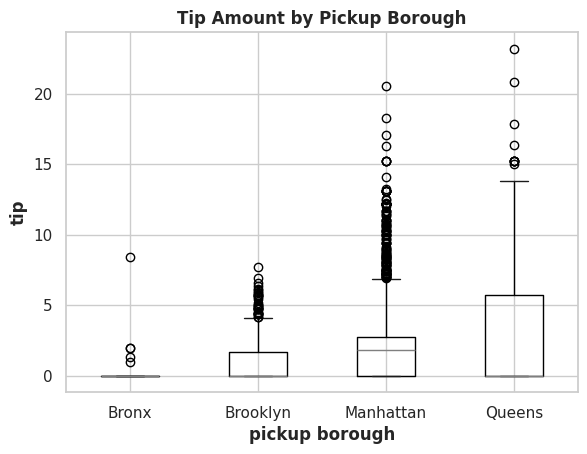

In [ ]:
# Plot a box plot to visualize the distribution of tip amounts for each pickup_borough. Use pickup_borough as the categorical axis and tip as the numeric axis.
df.boxplot(column='tip',by='pickup_borough')
plt.xlabel('pickup borough',fontweight='bold')
plt.ylabel('tip',fontweight='bold')
plt.title('Tip Amount by Pickup Borough',fontweight='bold')
plt.suptitle('')
plt.show()

**Insights:**
* Tip amounts are higher for Manhattan borugh where as Bronx has the lower tip amounts.

## **Visualizations using Seaborn:**

####**Count Plot**

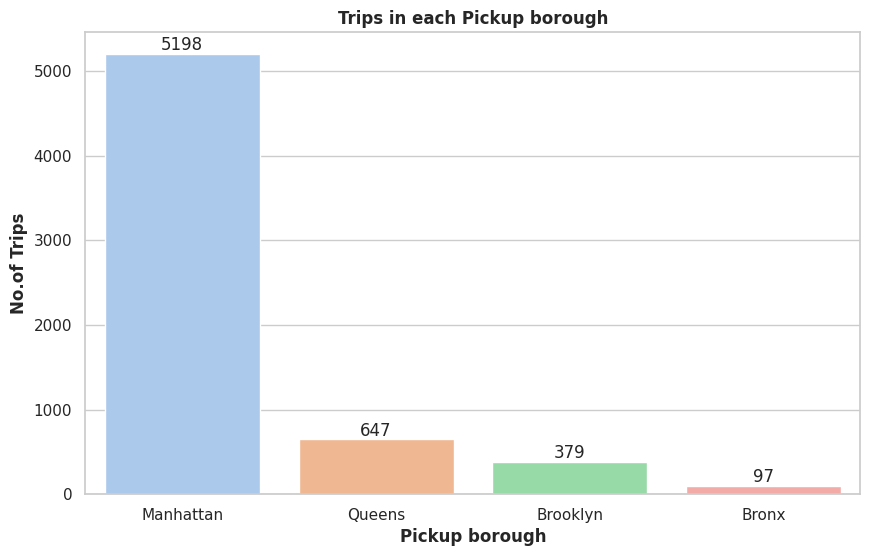

In [ ]:
# Create a count plot to visualize the number of trips in each pickup_borough. The x-axis should represent the boroughs, and the y-axis should show the count of trips.
plt.figure(figsize=(10,6))
ax=sns.countplot(x='pickup_borough',data=df,hue='pickup_borough',palette='pastel',legend=False)
plt.xlabel('Pickup borough',fontweight='bold')
plt.ylabel('No.of Trips',fontweight='bold')
plt.title('Trips in each Pickup borough',fontweight='bold')
for container in ax.containers:
  ax.bar_label(container)
plt.show()

**Insights:**
* Most trips are booked from Manhattan where as the least no of trips booked from Bronx.

####**Scatter Plot**

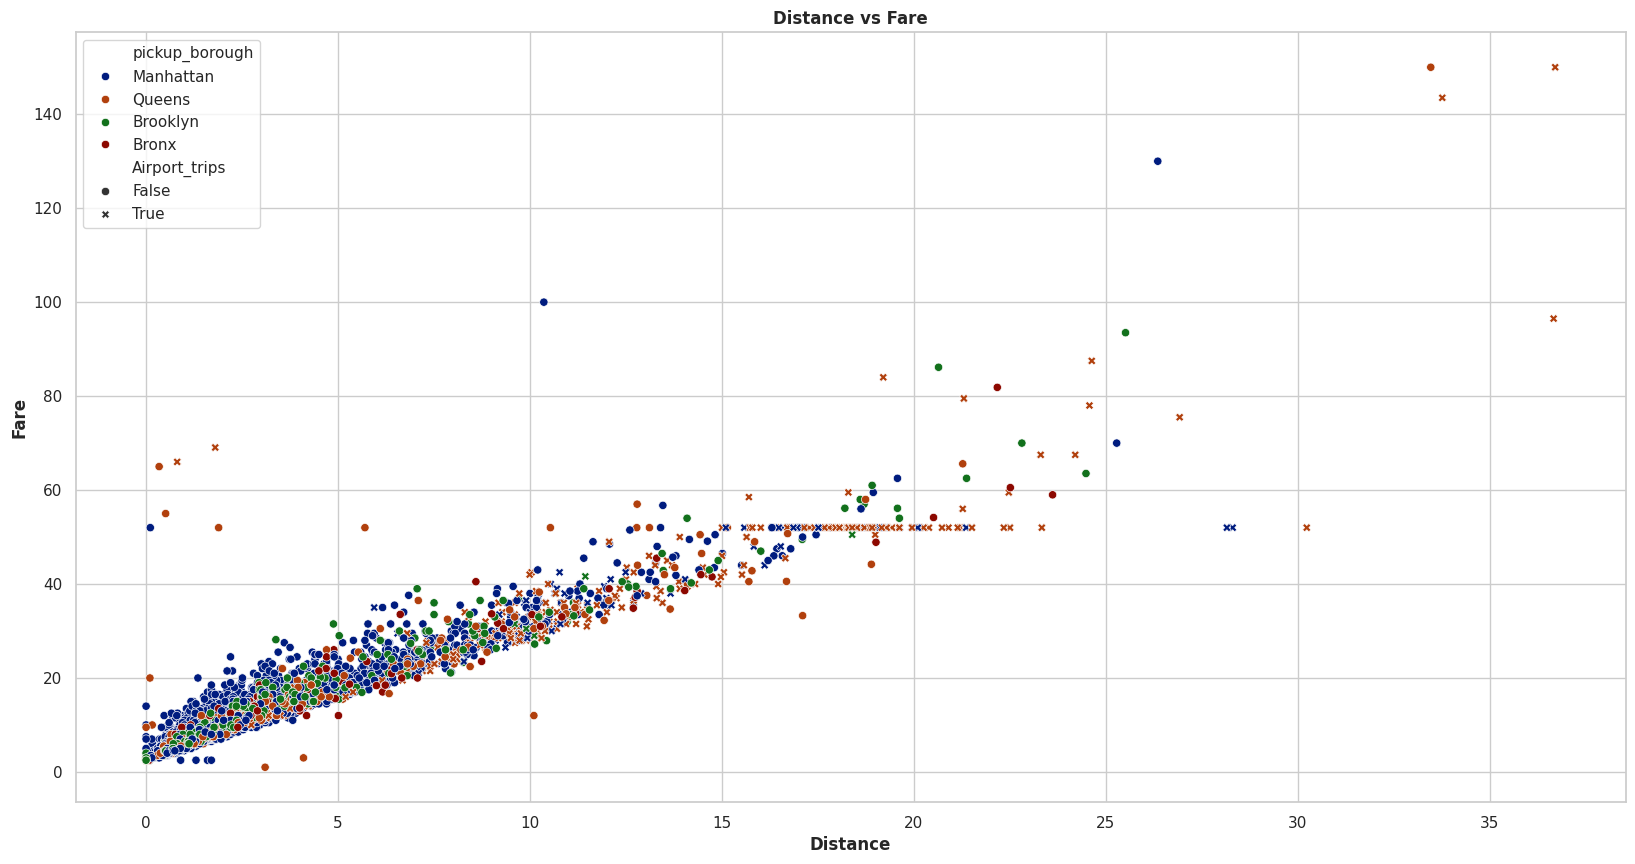

In [ ]:
#Plot a scatter plot to show the relationship between distance and fare. Use distance on the x-axis and fare on the y-axis to visualize any correlation. Color the points based on the pickup_borough to differentiate the trips by their respective boroughs.
df['Airport_trips']=(df['pickup_zone'].str.contains('Airport') | df['dropoff_zone'].str.contains('Airport'))
plt.figure(figsize=(20,10))
sns.scatterplot(x='distance',y='fare',data=df,hue='pickup_borough',style='Airport_trips')
plt.xlabel('Distance',fontweight='bold')
plt.ylabel('Fare',fontweight='bold')
plt.title('Distance vs Fare',fontweight='bold')
plt.show()

**Insights**
* Fare increases almost linearly with distance for normal trips.
* Some trips with similar distances have different fares, which may be due to tolls, traffic, peak-hour pricing, or airport charges.
* Most trips are concentrated in shorter distances (below 10 miles).
* Long-distance trips are comparatively fewer.
* Higher fare outliers are mostly present for long-distance trips.
* Airport trips are more visible in medium- to long-distance ranges.
* Manhattan trips appear more frequent compared to other boroughs.

####**Heatmap**

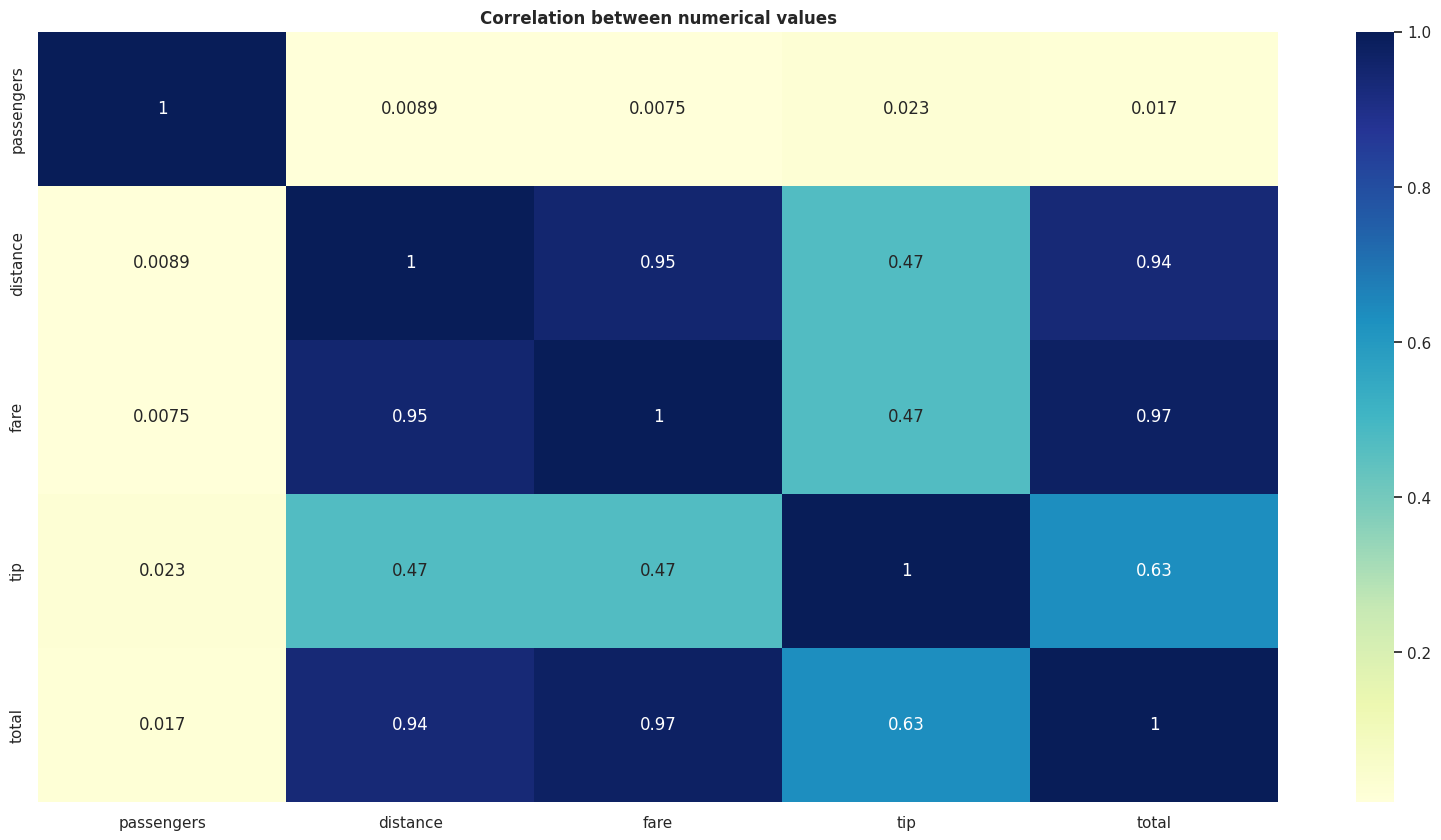

In [ ]:
# Plot a heatmap to visualize the correlation between numerical variables such as distance, fare, tip, tolls, and total. Use a correlation matrix to highlight the relationships.
plt.figure(figsize=(20,10))
cols=['passengers','distance','fare','tip','total']
sns.heatmap(df[cols].corr(),annot=True,cmap='YlGnBu')
plt.title("Correlation between numerical values",fontweight='bold')
plt.show()


**Insights**
* Distance and fare have a strong positive relationship.
* Fare and total amount are highly related.
* Distance and total amount also have a strong relationship.
* Tip has a moderate relationship with fare and distance.
* Passenger count has almost no relationship with other variables.

####**Pair Plot**

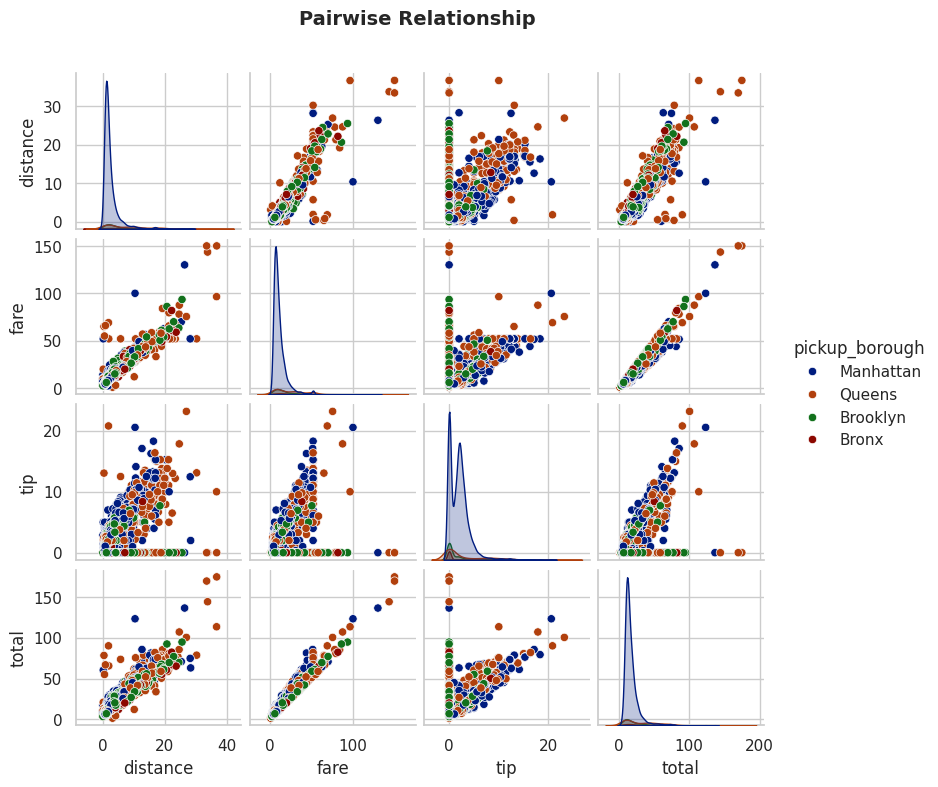

In [ ]:
# Create a pair plot to visualize the pairwise relationships between distance, fare, tip, and total. Color the data points according to the pickup_zone method to compare how different zones affect these variables.
a=sns.pairplot(df[['distance','fare','tip','total','pickup_borough']],hue='pickup_borough',height=2)
a.fig.suptitle("Pairwise Relationship",fontsize=14,fontweight='bold',x=0.45)
a.fig.subplots_adjust(top=0.9)
plt.show()

* Used pickup_borough instead of pickup_zone for better readability
because pickup_zone has many unique values.

**Insights:**
* Distance and fare have a linear relationship.
* Total amount increases as fare increases.
* Some trips have zero or lower tips even for longer distances.
* Most trips are concentrated in lower fare and shorter distance ranges.
* Manhattan trips appear more frequent compared to other boroughs

####**Violin Plot**

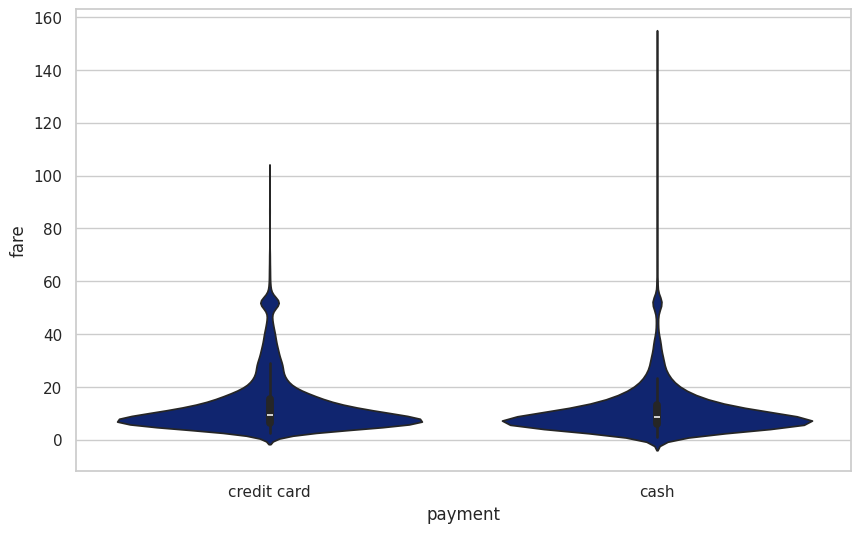

In [ ]:
# Plot a violin plot to show the distribution of fare for each payment method. Use the payment method as the categorical axis and fare as the numeric axis to visualize its distribution.
plt.figure(figsize=(10,6))
sns.violinplot(x='payment',y='fare',data=df)
plt.show()

* To show the main distribution more clearly and to hide extreme outliers visually limited y axis range to 60.

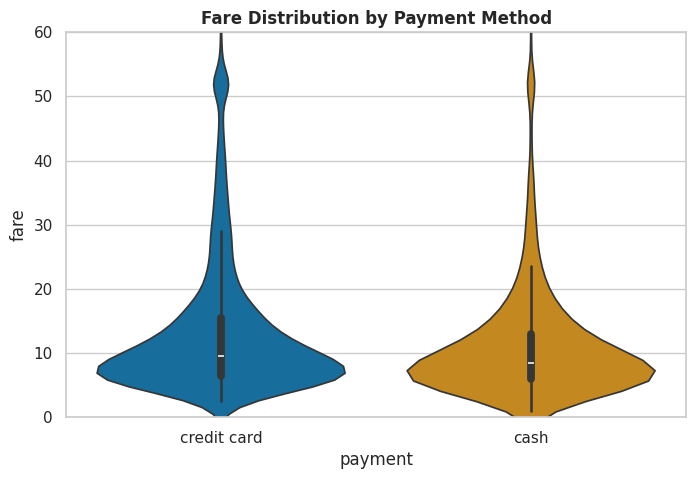

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(x='payment',y='fare',data=df,hue='payment',palette='colorblind')
plt.ylim(0,60)
plt.title("Fare Distribution by Payment Method",fontweight='bold')
plt.show()

**Insights:**
* Most fares are concentrated in lower fare ranges.
* Fare distribution is similar for both payment methods.
* Few trips have very high fares in both payment types.

## **Day wise revenue**

In [ ]:
df['day_name']=df['pickup'].dt.day_name()
Day_revenue=df.groupby('day_name')['total'].sum()
Day_revenue

,total
day_name,
Friday,20180.86
Monday,13110.35
Saturday,17772.76
Sunday,15017.34
Thursday,16869.85
Tuesday,15012.64
Wednesday,18255.79


* Friday generates the highest revenue where as monday generates the lowest revenue.



## **Passenger count effect on revenue**

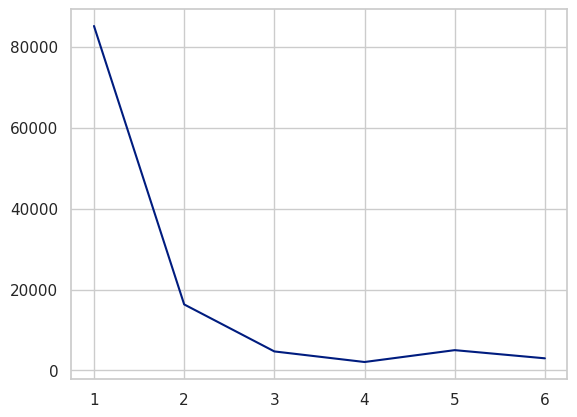

In [ ]:
revenue_pg=df.groupby('passengers')['total'].sum()
plt.plot(revenue_pg.index,revenue_pg.values)
plt.show()

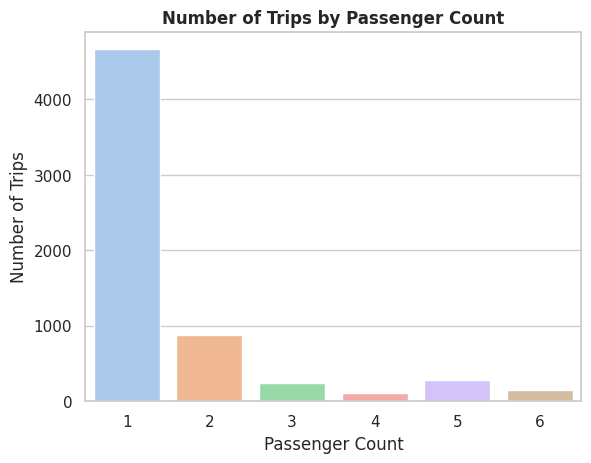

In [ ]:
sns.countplot(x='passengers',data=df,palette='pastel')

plt.title('Number of Trips by Passenger Count',fontweight='bold')
plt.xlabel('Passenger Count')
plt.ylabel('Number of Trips')

plt.show()

* Most taxi trips have only 1 passenger.
* As passenger count increases, the number of trips decreases.
* Higher revenue for 1 passenger trips is mainly due to more bookings.
* Passenger count alone does not strongly affect total revenue.
* This supports the weak correlation seen in the heatmap.


## **Customer satisfaction indicator based on the tip amount**

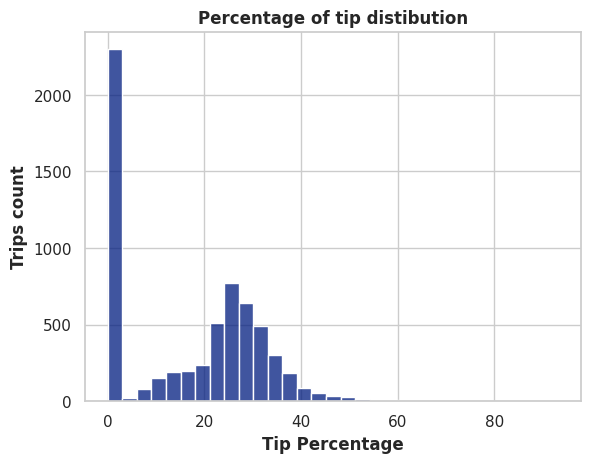

In [ ]:
df['tip_percent']=(df['tip']/df['fare'])*100
sns.histplot(df['tip_percent'])
plt.xlabel('Tip Percentage',fontweight='bold')
plt.ylabel('Trips count',fontweight='bold')
plt.title('Percentage of tip distibution',fontweight='bold')
plt.show()

* Most customers appear satisfied as moderate tip percentages are common.
* Some trips received low or no tips, indicating possible dissatisfaction.
* Very high tips are given only for a few trips.
* Overall customer feedback seems positive.

## **Final Conclusion**

* The analysis showed that trip distance is one of the major factors affecting taxi fare, while passenger count has very little influence on the total cost.
* Most passengers preferred short-distance travel and digital payment methods such as credit cards.
* The visualizations also highlighted that taxi demand is higher in certain boroughs and that customer tipping behavior varies across locations.
* Overall, the project demonstrated how data visualization can uncover hidden patterns, customer behavior, and operational trends from real-world transportation data.